# 11. 基于遮蔽攻击的对抗性训练

## 11.0 主要内容介绍

在之前的实验中，我们学习了基于模型可解释性之梯度积分法的遮蔽攻击（Inductive Occlusion Attack, IOA），以及基于PGD攻击的对抗性训练。

在本节中，我们将在MNIST数据集上实现遮蔽攻击，并基于遮蔽攻击进行专门的对抗性训练，以提升模型对遮蔽攻击的鲁棒性。

本实验的主要内容为采用Python、PyTorch、Captum等技术，实现基于遮蔽攻击的对抗性训练，并进行鲁棒性测试。

## 11.1 导入相关模块

In [3]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from occlusion_attack import OcclusionAttack
from adversarial_training import OcclusionAdversarialTraining
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 11.2 遮蔽攻击（Inductive Occlusion Attack）在MNIST上的实现

遮蔽攻击的核心思想是利用梯度积分（Integrated Gradients）来确定图像中最重要的区域，然后用特定颜色的遮蔽块覆盖这些区域，从而欺骗模型。

具体步骤为：
1. 使用梯度积分计算每个像素的重要性
2. 通过卷积操作计算每个区域的重要性之和
3. 选择最重要的top_k个区域中心
4. 用kernel_size × kernel_size的遮蔽窗口覆盖这些区域

与CIFAR-10上的实现不同，MNIST为单通道灰度图像（1×28×28），因此在卷积操作中输入通道数为1。

### 11.2.1 加载标准模型并测试遮蔽攻击效果

In [4]:
# 加载标准训练的LeNet5模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

print('标准LeNet5模型加载完成')

标准LeNet5模型加载完成


C:\Users\31198\AppData\Local\Temp\ipykernel_208472\3247200306.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  std_state = torch.load('./save_model/50epoch/mnist_lenet5.p

In [5]:
# 加载MNIST测试集
imgs, lbls = load_mnist_test()

# 测试标准模型在干净样本上的准确率
cln_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {cln_acc:.2f}%')

208472 20260328 16:04:35 标准模型 - 干净样本准确率: 99.00%
208472 20260328 16:04:35 标准模型 - 干净样本准确率: 99.00%


In [6]:
# 测试遮蔽攻击对标准模型的效果
occlusion = OcclusionAttack(std_lenet, top_k=9, occlu_color=0.0, kernel_size=3)
occ_acc, _ = test_fn(nn.Sequential(occlusion, std_lenet), imgs, lbls, bs=250, mode='attack')
logger.info(f'标准模型 - 遮蔽攻击后准确率: {occ_acc:.2f}%')

208472 20260328 16:04:42 标准模型 - 遮蔽攻击后准确率: 28.64%
208472 20260328 16:04:42 标准模型 - 遮蔽攻击后准确率: 28.64%


真实标签: 0


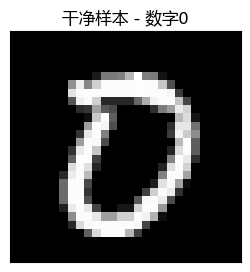

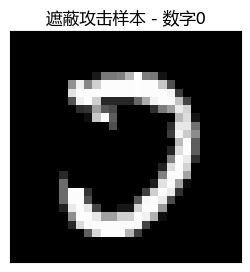

真实标签: 6


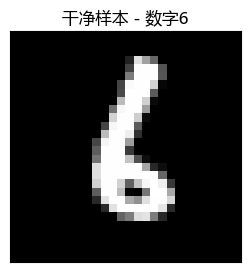

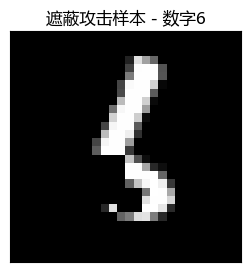

真实标签: 5


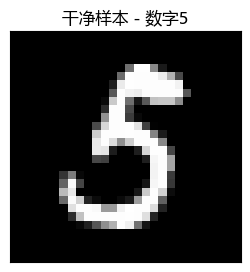

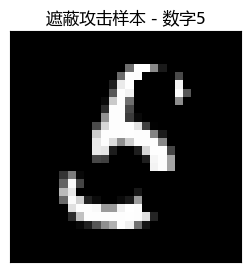

真实标签: 1


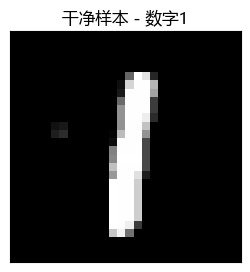

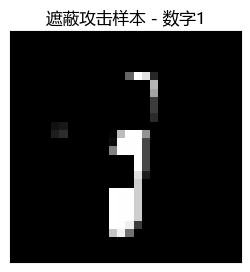

真实标签: 8


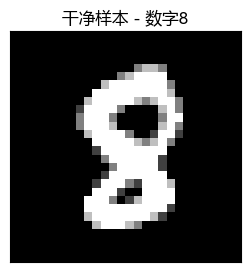

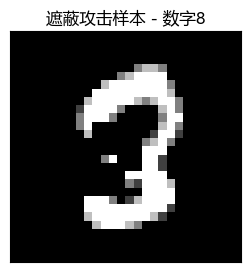

真实标签: 3


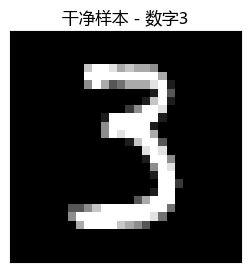

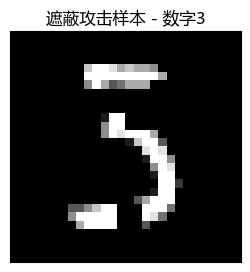

真实标签: 7


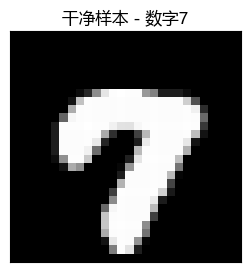

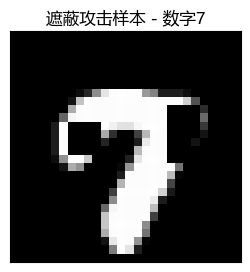

真实标签: 4


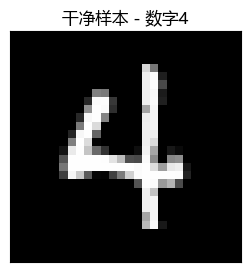

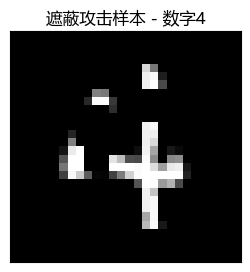

真实标签: 9


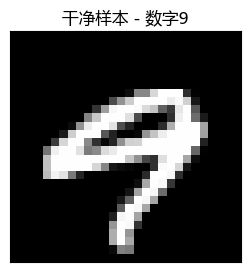

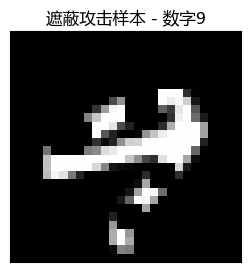

真实标签: 2


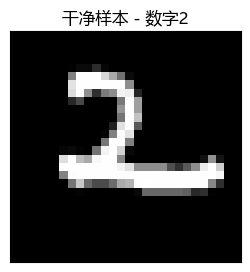

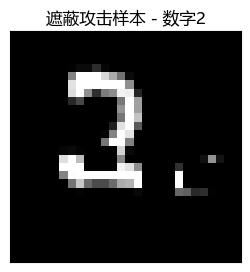

In [7]:
# 可视化遮蔽攻击效果
# 解决中文标题显示为方块/乱码（按顺序尝试可用中文字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def imshow_mnist(img, title=''):
    npimg = img.cpu().squeeze().numpy()
    plt.figure(figsize=(3, 3))
    plt.imshow(npimg, cmap='gray')
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()
# 取一个batch进行可视化（每个数字类别显示一个样本）
sample_x = imgs[:250].to(device)
sample_y = lbls[:250].to(device)
std_lenet.eval()
sample_adv = occlusion((sample_x, sample_y))

# 找到0-9每个数字在当前batch中的第一个样本索引
shown_labels = set()
selected_indices = []
for i in range(sample_y.shape[0]):
    label = int(sample_y[i].item())
    if label not in shown_labels:
        shown_labels.add(label)
        selected_indices.append(i)
    if len(shown_labels) == 10:
        break
for idx in selected_indices:
    label = int(sample_y[idx].item())
    print(f'真实标签: {label}')
    imshow_mnist(sample_x[idx], f'干净样本 - 数字{label}')
    imshow_mnist(sample_adv[idx], f'遮蔽攻击样本 - 数字{label}')


## 11.3 基于遮蔽攻击的对抗性训练

与PGD对抗性训练类似，基于遮蔽攻击的对抗性训练在每个训练步骤中：
1. 先对输入样本执行遮蔽攻击，生成对抗性样本
2. 然后用对抗性样本进行模型训练

通过OcclusionAdversarialTraining类，我们可以复用原有的训练代码，只需替换攻击方式即可。

In [8]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

TOP_K = 9               # 遮蔽攻击的top_k参数
OCCLU_COLOR = 0.0       # 遮蔽颜色（黑色）
KERNEL_SIZE = 3         # 遮蔽窗口大小

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [9]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [10]:
# 定义网络结构
cnn = LeNet5().to(device)
print(cnn)

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [10]:
# 构建基于遮蔽攻击的对抗性训练模型
cnn_oat = OcclusionAdversarialTraining(
    cnn, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE, is_at=True)

In [10]:
"""
    在cnn_oat.is_at = True的前提下，cnn_oat将先对输入的任何样本进行遮蔽攻击再进行测试。
因此，此处的train_accs, train_losses, test_accs, test_losses与以往实验中的含义不
同，它们均为经过遮蔽攻击后的指标。
"""
train_accs = []
train_losses = []
test_accs = []
test_losses = []

for epoch in range(EPOCH):
    # 训练
    cnn_oat.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_oat(inputs, labels)

        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.max(dim=1).indices        
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n
        
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, loss: {train_loss / train_total:.2f}, acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn_oat.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_oat(inputs, labels)
            loss = loss_function(outputs, labels)

            pred = outputs.max(dim=1).indices  
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, loss: {test_loss / test_total:.2f}, acc: {100 * test_correct / test_total:.2f}%')

 32996 20260315 23:38:36 training epoch: 0, loss: 1.17, acc: 60.94%
 32996 20260315 23:38:45     test epoch: 0, loss: 0.73, acc: 75.70%
 32996 20260315 23:39:38 training epoch: 1, loss: 0.62, acc: 79.80%
 32996 20260315 23:39:47     test epoch: 1, loss: 0.52, acc: 82.89%
 32996 20260315 23:40:41 training epoch: 2, loss: 0.46, acc: 84.98%
 32996 20260315 23:40:51     test epoch: 2, loss: 0.38, acc: 87.63%
 32996 20260315 23:41:45 training epoch: 3, loss: 0.36, acc: 88.36%
 32996 20260315 23:41:54     test epoch: 3, loss: 0.33, acc: 89.02%
 32996 20260315 23:42:49 training epoch: 4, loss: 0.29, acc: 90.42%
 32996 20260315 23:42:59     test epoch: 4, loss: 0.25, acc: 91.56%
 32996 20260315 23:44:20 training epoch: 5, loss: 0.25, acc: 91.91%
 32996 20260315 23:44:34     test epoch: 5, loss: 0.24, acc: 92.13%
 32996 20260315 23:45:52 training epoch: 6, loss: 0.21, acc: 93.09%
 32996 20260315 23:46:04     test epoch: 6, loss: 0.20, acc: 93.34%
 32996 20260315 23:47:16 training epoch: 7, loss

In [11]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_OcclusionAT_{TOP_K}_{KERNEL_SIZE}.pth')

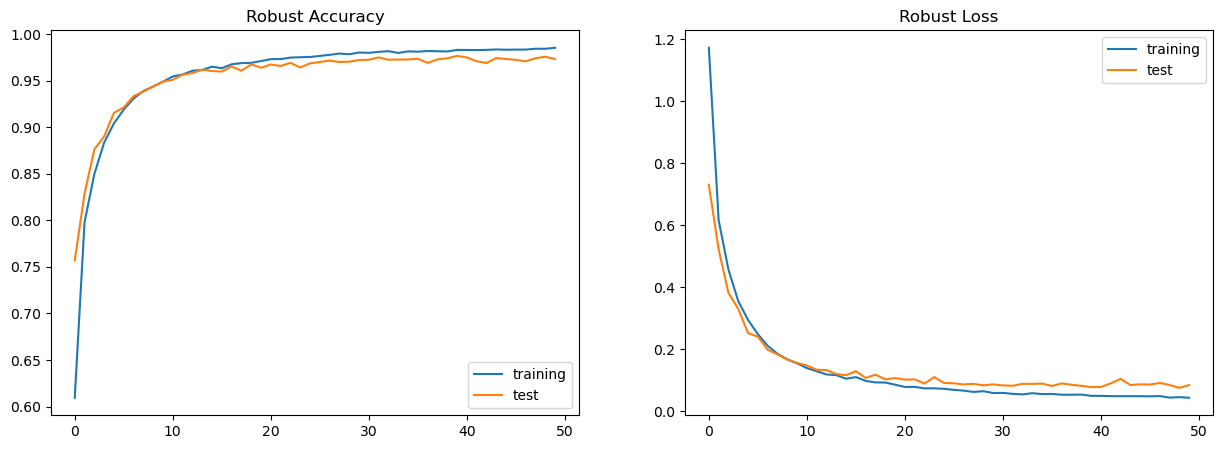

In [12]:
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Robust Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Robust Loss')

plt.show()

## 11.4 鲁棒性测试

### 11.4.0 遮蔽攻击测试

In [13]:
# 加载样本
imgs, lbls = load_mnist_test()

# 遮蔽攻击测试
occlusion = OcclusionAttack(cnn, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
occ_acc, _ = test_fn(nn.Sequential(occlusion, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'遮蔽攻击AT模型 - Clean: {cln_acc:.2f}, Occlusion Attack: {occ_acc:.2f}')

 32996 20260316 00:42:03 遮蔽攻击AT模型 - Clean: 95.75, Occlusion Attack: 97.34


### 11.4.1 白盒攻击测试（PGD, FGSM, CW）

In [14]:
EPS = 0.1

# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'遮蔽攻击AT模型 - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}, Occlusion: {occ_acc:.2f}')

 32996 20260316 00:42:06 遮蔽攻击AT模型 - Clean: 95.75, FGSM: 3.24, PGD: 0.00, CW: 0.00, Occlusion: 97.34


### 11.4.2 迁移攻击测试

In [15]:
# 使用标准模型作为替代模型进行迁移攻击
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义迁移攻击参数（基于标准模型生成对抗性样本，测试遮蔽攻击AT模型）
FGSM_kwargs = dict(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 遮蔽迁移攻击
occlusion_transfer = OcclusionAttack(std_lenet, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

# 执行迁移攻击测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')
trans_occ_acc, _ = test_fn(nn.Sequential(occlusion_transfer, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'迁移攻击 - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}, Occlusion: {trans_occ_acc:.2f}')

C:\Users\31198\AppData\Local\Temp\ipykernel_32996\1365538889.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  std_state = torch.load('./save_model/50epoch/mnist_lenet5.pt

### 11.4.3 结果汇总

In [16]:
headers = ['模型', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion']
table = [
    ['遮蔽攻击AT (白盒)', f'{cln_acc:.2f}', f'{fgsm_acc:.2f}', f'{pgd_acc:.2f}', f'{cw_acc:.2f}', f'{occ_acc:.2f}'],
    ['遮蔽攻击AT (迁移)', f'{cln_acc:.2f}', f'{trans_fgsm_acc:.2f}', f'{trans_pgd_acc:.2f}', f'{trans_cw_acc:.2f}', f'{trans_occ_acc:.2f}'],
]
print(tabulate(table, headers=headers, tablefmt='grid'))

+-------------------+---------+--------+-------+-------+-------------+
| 模型              |   Clean |   FGSM |   PGD |    CW |   Occlusion |
+===================+=========+========+=======+=======+=============+
| 遮蔽攻击AT (白盒) |   95.75 |   3.24 |  0    |  0    |       97.34 |
+-------------------+---------+--------+-------+-------+-------------+
| 遮蔽攻击AT (迁移) |   95.75 |  88.13 | 89.67 | 91.79 |       94.77 |
+-------------------+---------+--------+-------+-------+-------------+


In [12]:
import sys
from pathlib import Path

# 将 AutoAttack 源码目录加入路径
_aa_root = Path('.').resolve() / 'auto-attack' / 'auto-attack-master'
if _aa_root.is_dir():
    sys.path.insert(0, str(_aa_root))

# 加载 checkpoint：权重在字典的 'net' 键中
ckpt = torch.load(
    './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    map_location=device,
)
cnn = LeNet5()
cnn.load_state_dict(ckpt['net'])
cnn = cnn.to(device)
cnn.eval()

from autoattack import AutoAttack

# load_mnist_test 使用 ToTensor，像素在 [0,1]；Linf 常用 eps=8/255（与 CIFAR 论文设置一致）
#EPS = 8.0 / 255.0
#N_EX = 1000  # 标准 AutoAttack 较慢；评估全测试集可改为 None

#imgs, lbls = load_mnist_test(n_examples=N_EX)
imgs, lbls = load_mnist_test()
lbls = lbls.long()

adversary = AutoAttack(
    cnn,
    norm='Linf',
    eps=0.1,
    version='standard',
    device=str(device),
    verbose=True,
)
x_adv = adversary.run_standard_evaluation(imgs, lbls, bs=250)

C:\Users\31198\AppData\Local\Temp\ipykernel_81532\2956670951.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(


setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 95.75%
apgd-ce - 1/39 - 250 out of 250 successfully perturbed
apgd-ce - 2/39 - 250 out of 250 successfully perturbed
apgd-ce - 3/39 - 250 out of 250 successfully perturbed
apgd-ce - 4/39 - 250 out of 250 successfully perturbed
apgd-ce - 5/39 - 250 out of 250 successfully perturbed
apgd-ce - 6/39 - 250 out of 250 successfully perturbed
apgd-ce - 7/39 - 250 out of 250 successfully perturbed
apgd-ce - 8/39 - 250 out of 250 successfully perturbed
apgd-ce - 9/39 - 250 out of 250 successfully perturbed
apgd-ce - 10/39 - 250 out of 250 successfully perturbed
apgd-ce - 11/39 - 250 out of 250 successfully perturbed
apgd-ce - 12/39 - 250 out of 250 successfully perturbed
apgd-ce - 13/39 - 250 out of 250 successfully perturbed
apgd-ce - 14/39 - 250 out of 250 successfully perturbed
apgd-ce - 15/39 - 250 out of 250 successfully perturbed
apgd-ce - 16/39 - 250 out of 250 succes

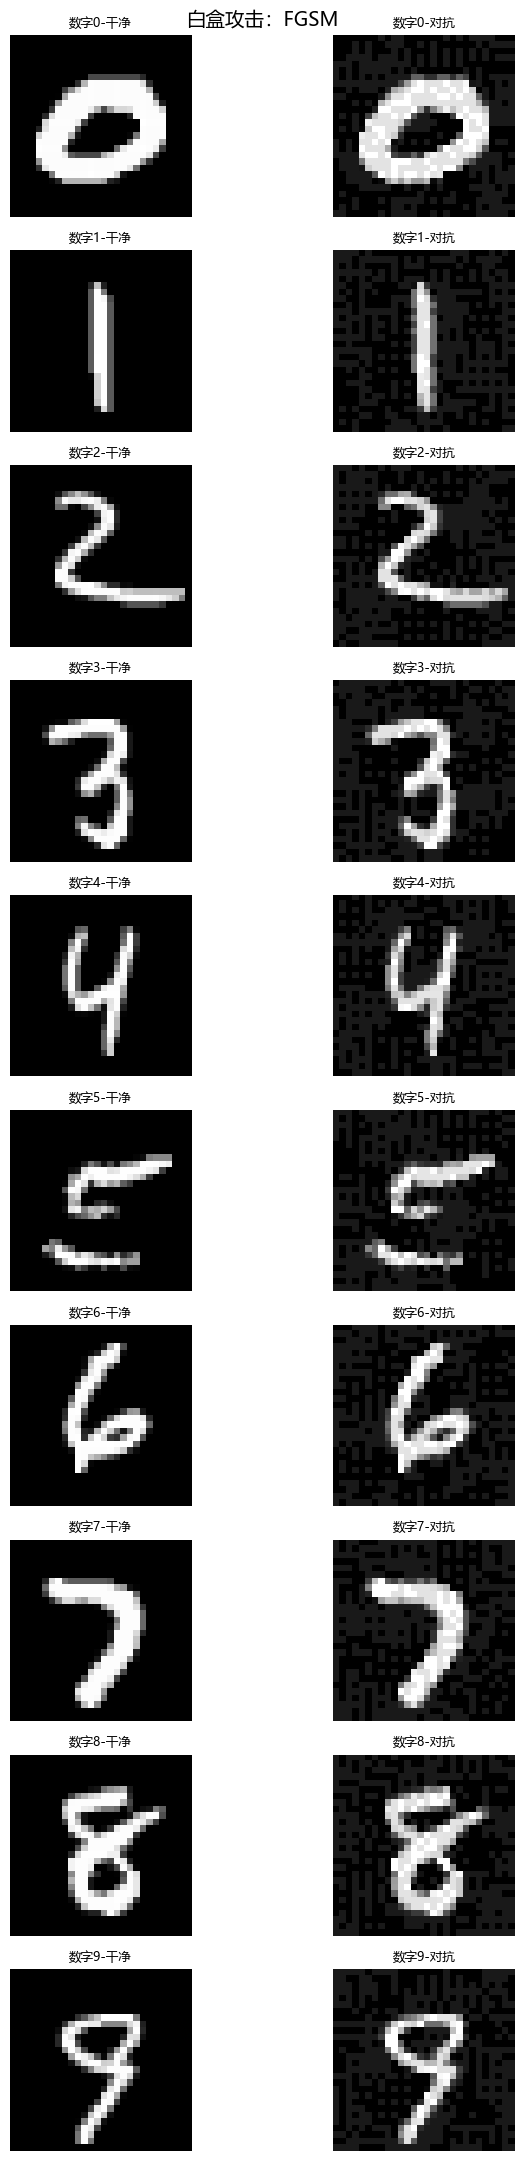

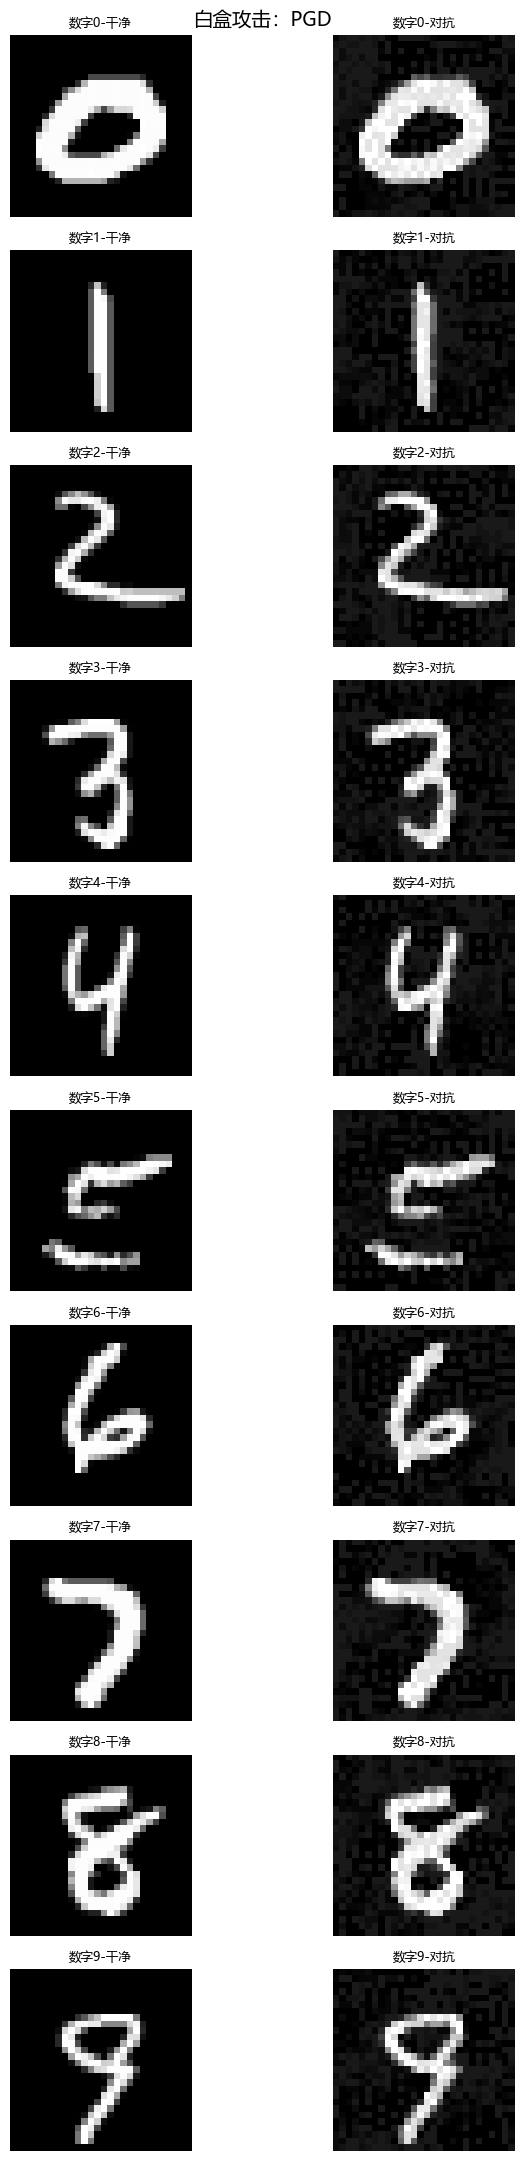

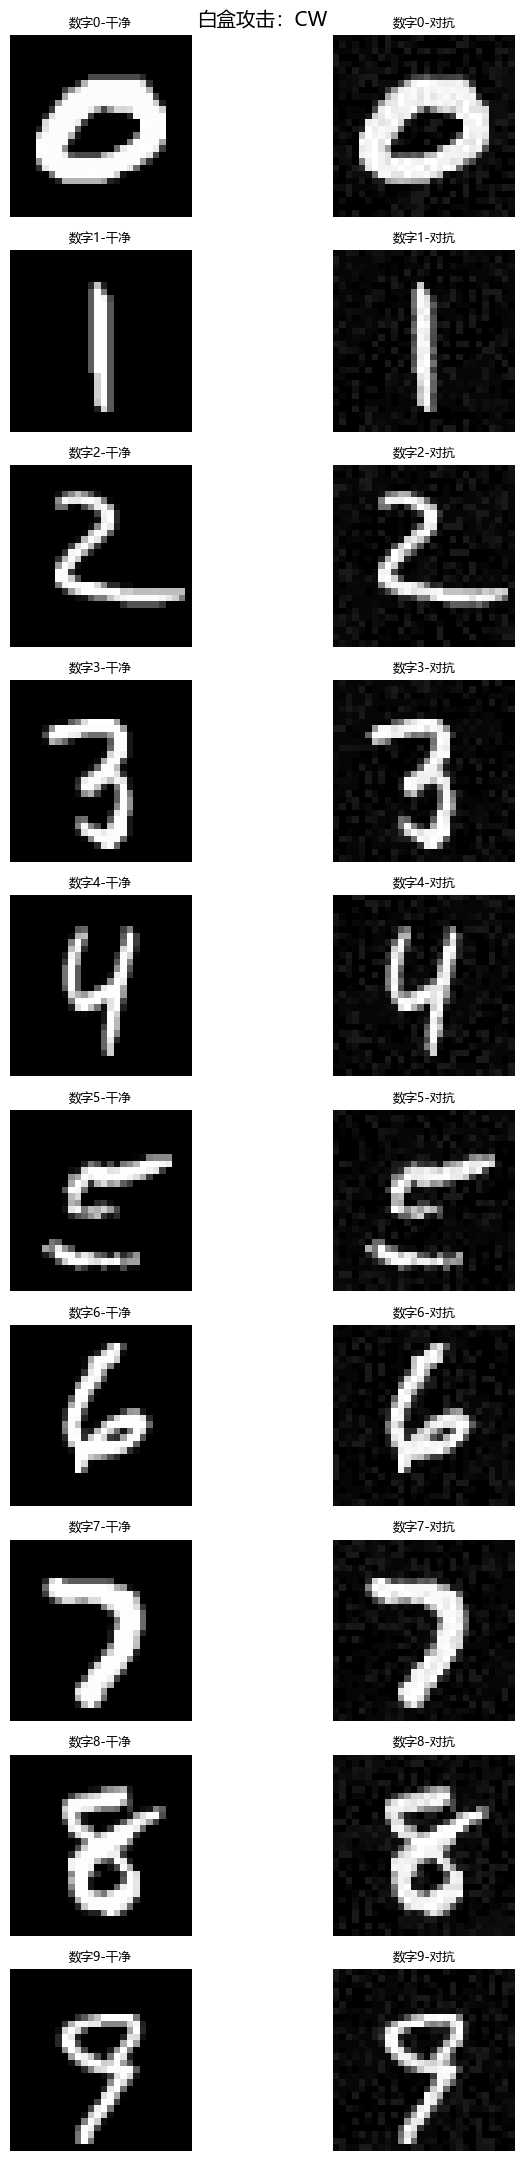

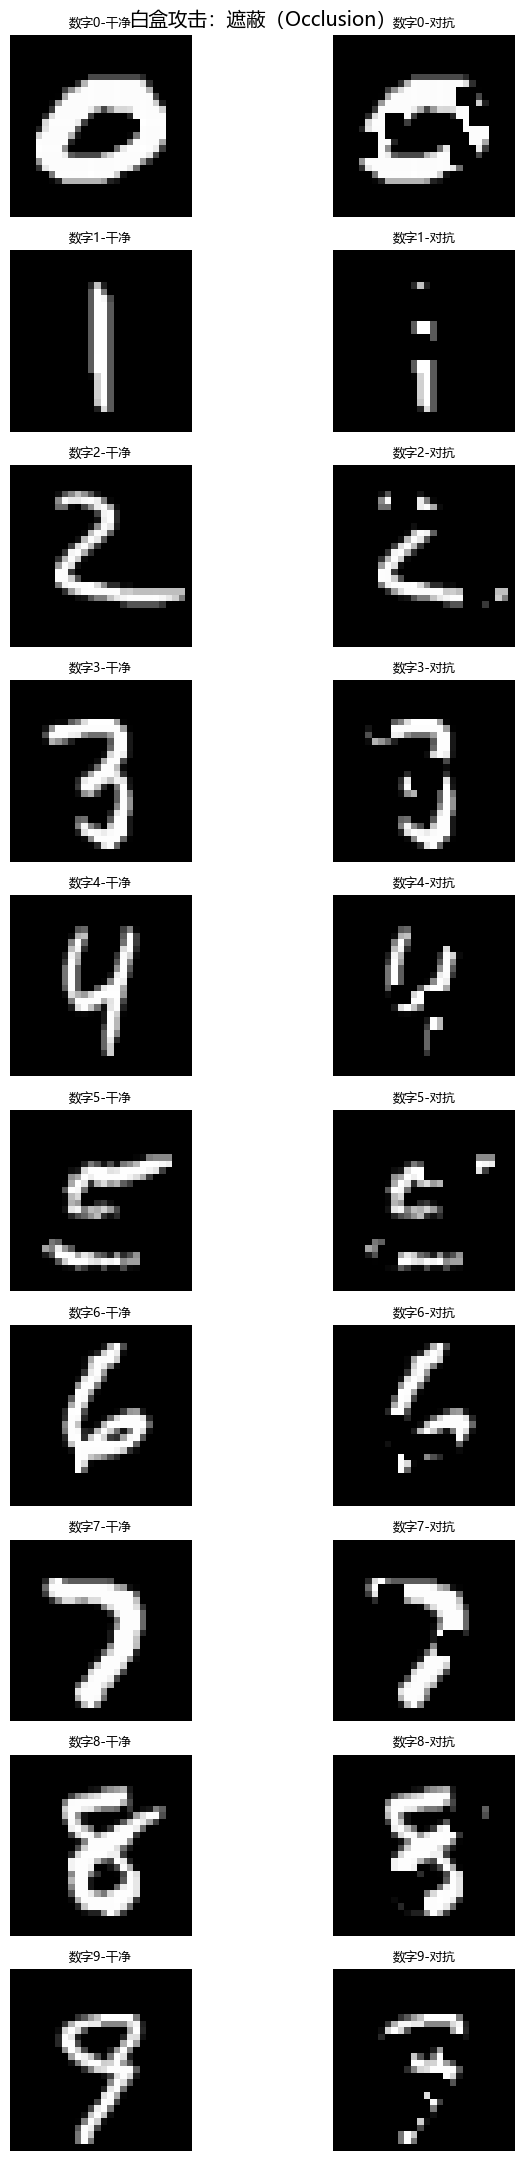

C:\Users\31198\AppData\Local\Temp\ipykernel_81532\1080179550.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  std_state = torch.load('./save_model/50epoch/mnist_lenet5.

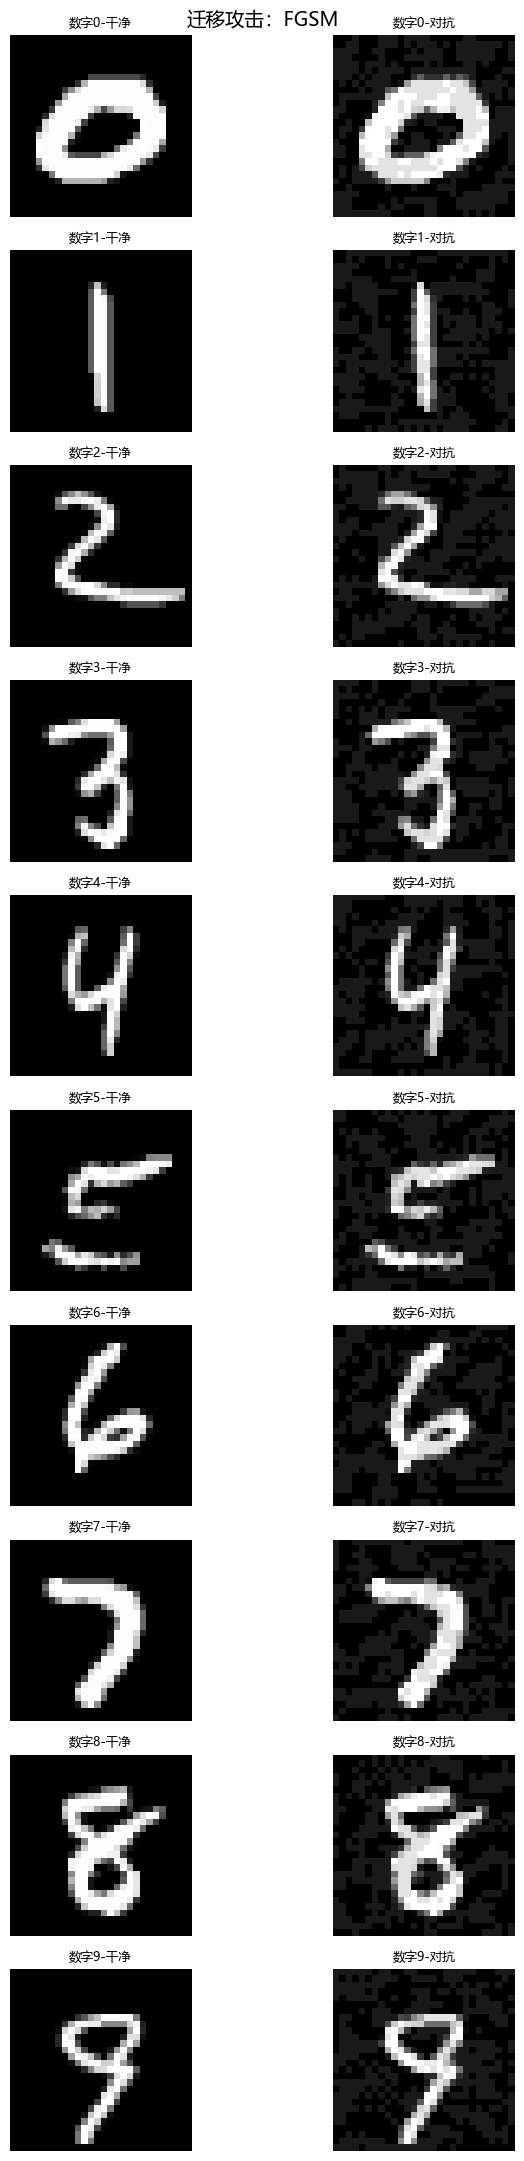

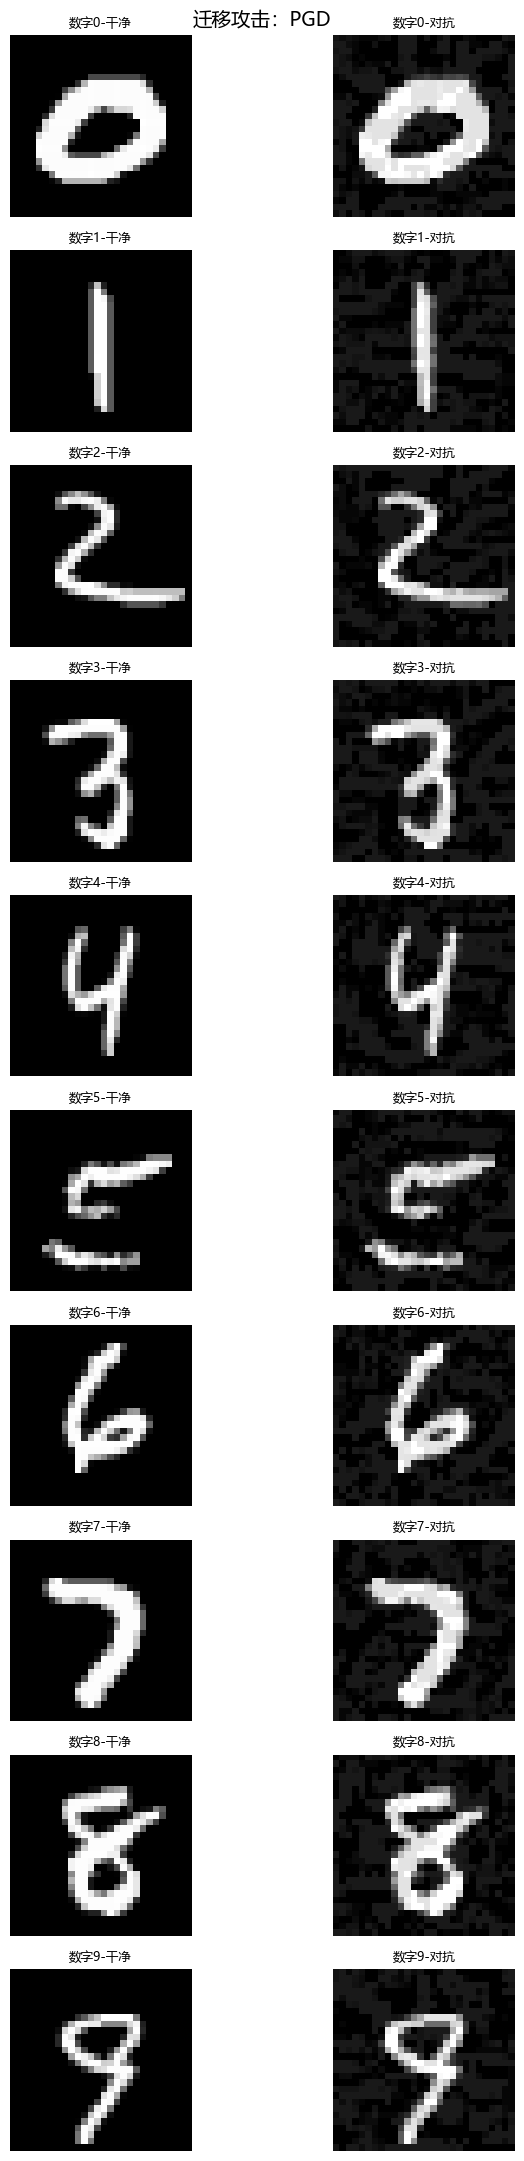

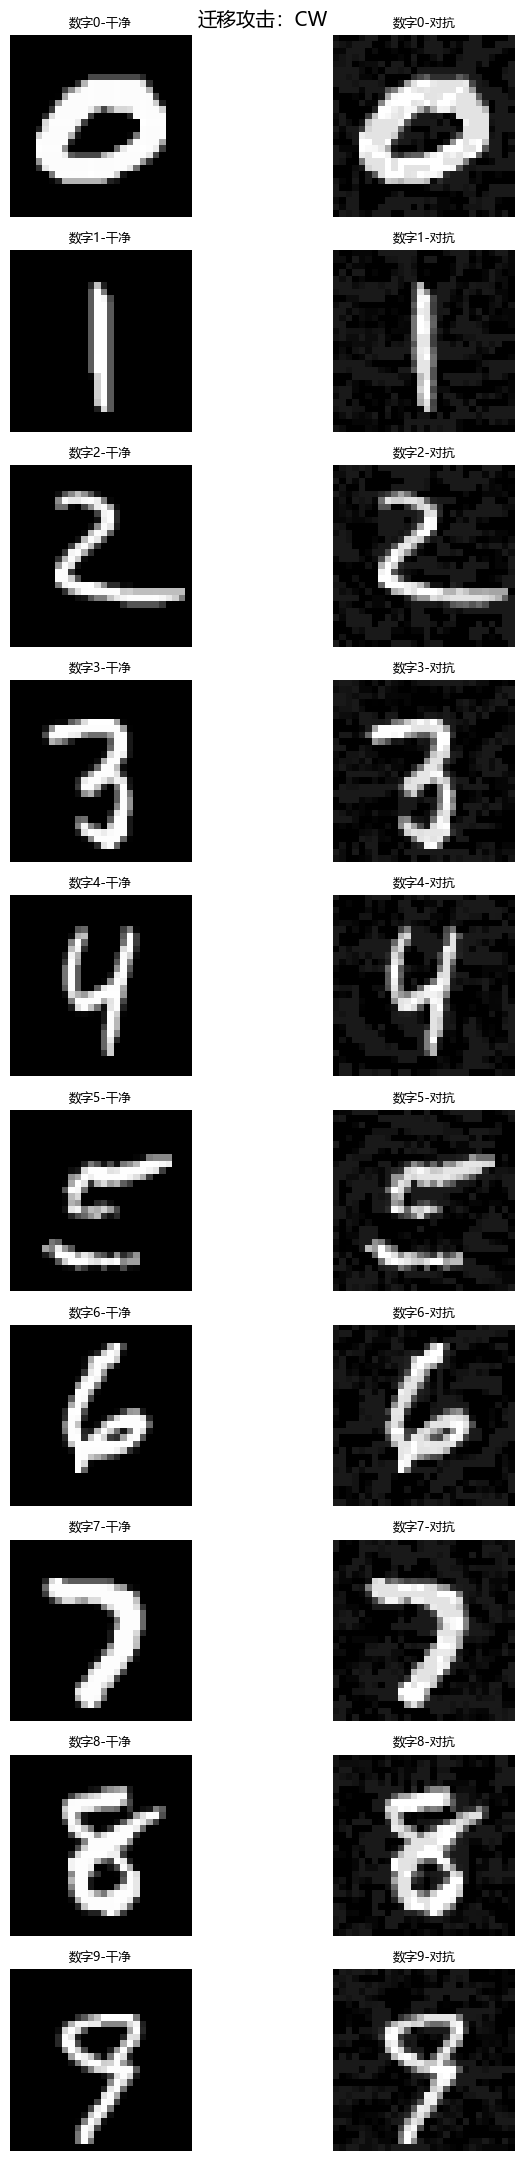

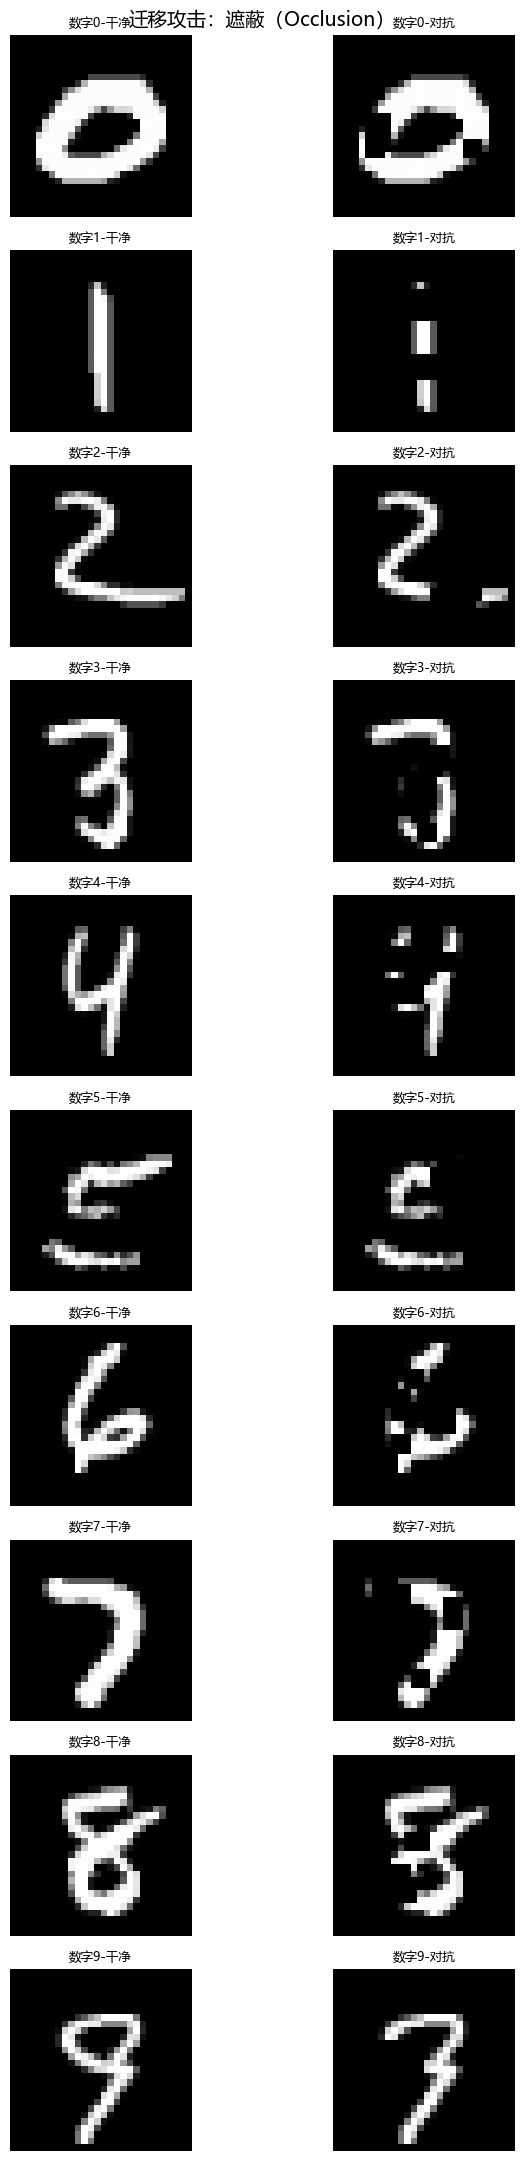

In [14]:
# 白盒攻击 vs 迁移攻击：对抗样本可视化
import matplotlib.pyplot as plt

# 中文字体/负号兼容
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


def to_numpy(img):
    """把(1,28,28) tensor 转成(28,28)用于imshow"""
    return img.detach().cpu().squeeze().numpy()


def select_one_per_digit(imgs_tensor, lbls_tensor):
    """从整个测试集中抽取0-9各一个样本，返回digit_order对应的索引列表"""
    label_to_idx = {}
    for i in range(lbls_tensor.shape[0]):
        label = int(lbls_tensor[i].item())
        if label not in label_to_idx:
            label_to_idx[label] = i
        if len(label_to_idx) == 10:
            break
    # 按数字0-9顺序组织
    selected = []
    for d in range(10):
        if d in label_to_idx:
            selected.append(label_to_idx[d])
        else:
            selected.append(None)
    return selected


def plot_clean_and_adv(x_clean_10, x_adv_10, fig_title):
    """画1张大图：10行2列；每行=数字d；左列干净，右列对抗"""
    fig, axes = plt.subplots(10, 2, figsize=(8, 22))

    # axes[d, 0]：干净；axes[d, 1]：对抗
    for d in range(10):
        ax_clean = axes[d, 0]
        ax_adv = axes[d, 1]

        ax_clean.set_xticks([])
        ax_clean.set_yticks([])
        ax_adv.set_xticks([])
        ax_adv.set_yticks([])

        ax_clean.set_title(f'数字{d}-干净', fontsize=9)
        ax_adv.set_title(f'数字{d}-对抗', fontsize=9)

        img_clean = x_clean_10[d]
        img_adv = x_adv_10[d]

        ax_clean.imshow(to_numpy(img_clean), cmap='gray')
        ax_clean.axis('off')

        ax_adv.imshow(to_numpy(img_adv), cmap='gray')
        ax_adv.axis('off')

    fig.suptitle(fig_title, fontsize=14)
    plt.tight_layout()
    plt.show()


# 准备数据
if 'imgs' not in globals() or 'lbls' not in globals():
    imgs, lbls = load_mnist_test()

# 攻击参数（与前文保持一致）
EPS = 0.1

TOP_K_ = globals().get('TOP_K', 9)
OCCLU_COLOR_ = globals().get('OCCLU_COLOR', 0.0)
KERNEL_SIZE_ = globals().get('KERNEL_SIZE', 3)

# 选择0-9每个数字一个样本（仅取10张用于可视化，加快计算）
selected_indices = select_one_per_digit(imgs, lbls)

# 若个别数字缺失，给出提示
if any(s is None for s in selected_indices):
    raise RuntimeError(f'用于可视化的样本不足，缺失数字: {[i for i,s in enumerate(selected_indices) if s is None]}')

x_clean = imgs[selected_indices].to(device)
# x_clean 的第0维顺序即 digit=0..9

# ========== 1) 白盒攻击（针对cnn）==========
cnn.eval()

FGSM_w = LinfPGD(net=cnn, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_w = LinfPGD(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_w = LinfPGD(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
Occl_w = OcclusionAttack(cnn, top_k=TOP_K_, occlu_color=OCCLU_COLOR_, kernel_size=KERNEL_SIZE_)

# 注意：LinfPGD/ OcclusionAttack forward 需要输入(x,y)
# y 用于计算loss/target，因此需要从对应索引取标签
y_clean = lbls[selected_indices].to(device)

x_adv_fgsm_white = FGSM_w((x_clean, y_clean))
x_adv_pgd_white = PGD_w((x_clean, y_clean))
x_adv_cw_white = CW_w((x_clean, y_clean))
x_adv_occl_white = Occl_w((x_clean, y_clean))

plot_clean_and_adv(x_clean, x_adv_fgsm_white, '白盒攻击：FGSM')
plot_clean_and_adv(x_clean, x_adv_pgd_white, '白盒攻击：PGD')
plot_clean_and_adv(x_clean, x_adv_cw_white, '白盒攻击：CW')
plot_clean_and_adv(x_clean, x_adv_occl_white, '白盒攻击：遮蔽（Occlusion）')


# ========== 2) 迁移攻击（来源std_lenet，测试cnn）==========
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

FGSM_t = LinfPGD(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_t = LinfPGD(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_t = LinfPGD(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
Occl_t = OcclusionAttack(std_lenet, top_k=TOP_K_, occlu_color=OCCLU_COLOR_, kernel_size=KERNEL_SIZE_)

x_adv_fgsm_transfer = FGSM_t((x_clean, y_clean))
x_adv_pgd_transfer = PGD_t((x_clean, y_clean))
x_adv_cw_transfer = CW_t((x_clean, y_clean))
x_adv_occl_transfer = Occl_t((x_clean, y_clean))

plot_clean_and_adv(x_clean, x_adv_fgsm_transfer, '迁移攻击：FGSM')
plot_clean_and_adv(x_clean, x_adv_pgd_transfer, '迁移攻击：PGD')
plot_clean_and_adv(x_clean, x_adv_cw_transfer, '迁移攻击：CW')
plot_clean_and_adv(x_clean, x_adv_occl_transfer, '迁移攻击：遮蔽（Occlusion）')


In [10]:
logger_.handlers = logger_.handlers[:1]

In [11]:
# 遮蔽攻击 + PGD 混合样本对抗性训练（新方法）
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

from pgd import LinfPGD
from occlusion_attack import OcclusionAttack


class OcclusionPgdMixedAdversarialTraining(nn.Module):
    """把一个batch里的样本按比例替换为：一部分=遮蔽攻击样本，一部分=PGD攻击样本。"""

    def __init__(
        self,
        model,
        top_k=9,
        occlu_color=0.0,
        kernel_size=3,
        eps=0.1,
        pgd_step=20,
        pgd_step_size=0.025,
        random_start=True,
        occlu_ratio=0.5,
        criterion=F.cross_entropy,
    ):
        super().__init__()
        self.model = model
        self.occlu_ratio = occlu_ratio

        # 生成对抗样本：遮蔽攻击 + PGD(L_inf)
        self.occlusion = OcclusionAttack(
            self.model,
            top_k=top_k,
            occlu_color=occlu_color,
            kernel_size=kernel_size,
        )
        self.pgd = LinfPGD(
            net=self.model,
            eps=eps,
            step_size=pgd_step_size,
            step=pgd_step,
            random_start=random_start,
            criterion=criterion,
        )

    def forward(self, x, y=None):
        if y is None:
            return self.model(x)

        training = self.model.training
        assert y is not None

        # 对抗样本生成阶段固定为eval（与其它AT实现一致）
        self.model.eval()

        bs = x.size(0)
        k = int(bs * self.occlu_ratio)

        if k <= 0:
            x_mix = self.pgd((x, y))
        elif k >= bs:
            x_mix = self.occlusion((x, y))
        else:
            x_adv_occl = self.occlusion((x, y))
            x_adv_pgd = self.pgd((x, y))

            # 保持batch大小不变：前k个用遮蔽，其余用PGD
            x_mix = x_adv_pgd.clone()
            x_mix[:k] = x_adv_occl[:k]

        # 恢复训练模式
        if training:
            self.model.train()

        return self.model(x_mix)


# ========== 训练配置（按需修改）==========
EPOCH_MIX = 10
LR_MIX = 0.001

# PGD参数（L_inf）
EPS = 0.1
PGD_STEP = 20
PGD_STEP_SIZE = 0.025
RANDOM_START = True

# 混合比例：前k个走遮蔽，其余走PGD
OCCLU_RATIO = 0.5

# occlusion参数复用你前面定义的TOP_K / OCCLU_COLOR / KERNEL_SIZE
TOP_K_ = globals().get('TOP_K', 9)
OCCLU_COLOR_ = globals().get('OCCLU_COLOR', 0.0)
KERNEL_SIZE_ = globals().get('KERNEL_SIZE', 3)

# logger 兼容 + 日志保护：避免重复 StreamHandler 导致一条日志打印多遍
import logging

logger_ = globals().get('logger', None)
if logger_ is None:
    logger_ = logging.getLogger('base')
    logger_.setLevel(logging.DEBUG)

_stream_hs = [h for h in logger_.handlers if isinstance(h, logging.StreamHandler)]
if not _stream_hs:
    _h = logging.StreamHandler()
    _h.setLevel(logging.DEBUG)
    logger_.addHandler(_h)
else:
    for _h in _stream_hs[1:]:
        logger_.removeHandler(_h)

# ========== 构建模型与训练模块==========
cnn_mix = LeNet5().to(device)
cnn_mix_at = OcclusionPgdMixedAdversarialTraining(
    cnn_mix,
    top_k=TOP_K_,
    occlu_color=OCCLU_COLOR_,
    kernel_size=KERNEL_SIZE_,
    eps=EPS,
    pgd_step=PGD_STEP,
    pgd_step_size=PGD_STEP_SIZE,
    random_start=RANDOM_START,
    occlu_ratio=OCCLU_RATIO,
    criterion=F.cross_entropy,
)

optimizer_mix = torch.optim.Adam(cnn_mix.parameters(), lr=LR_MIX)
loss_function_ = nn.CrossEntropyLoss()


# ========== 训练/测试循环==========
train_accs, train_losses, test_accs, test_losses = [], [], [], []
train_clean_accs, test_clean_accs = [], []

for epoch in range(EPOCH_MIX):
    # 训练（对抗训练：模型内部会对inputs做混合攻击）
    cnn_mix_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_mix_at(inputs, labels)
        loss = loss_function_(outputs, labels)

        optimizer_mix.zero_grad()
        loss.backward()
        optimizer_mix.step()

        pred = outputs.max(dim=1).indices
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.item() * n

    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total

    # 干净样本准确率（不传 labels，走 forward 的干净分支）
    _was_train = cnn_mix_at.training
    cnn_mix_at.eval()
    train_clean_correct = 0
    with torch.no_grad():
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            pred_c = cnn_mix_at(inputs).max(dim=1).indices
            train_clean_correct += (pred_c == labels).sum().item()
    train_clean_acc = train_clean_correct / train_total
    if _was_train:
        cnn_mix_at.train()

    logger_.info(
        f'mix-AT train epoch: {epoch}, loss: {train_loss_avg:.2f}, '
        f'mix-acc: {100 * train_acc:.2f}%, clean-acc: {100 * train_clean_acc:.2f}%'
    )

    # 测试：同批次先算干净 acc，再走混合对抗（与训练一致）
    cnn_mix_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_clean_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)

            pred_clean = cnn_mix_at(inputs).max(dim=1).indices
            test_clean_correct += (pred_clean == labels).sum().item()

            outputs = cnn_mix_at(inputs, labels)
            loss = loss_function_(outputs, labels)

            pred = outputs.max(dim=1).indices
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n

    test_acc = test_correct / test_total
    test_clean_acc = test_clean_correct / test_total
    test_loss_avg = test_loss / test_total
    logger_.info(
        f'    mix-AT test epoch: {epoch}, loss: {test_loss_avg:.2f}, '
        f'mix-acc: {100 * test_acc:.2f}%, clean-acc: {100 * test_clean_acc:.2f}%'
    )

    train_accs.append(train_acc)
    train_losses.append(train_loss_avg)
    train_clean_accs.append(train_clean_acc)
    test_accs.append(test_acc)
    test_losses.append(test_loss_avg)
    test_clean_accs.append(test_clean_acc)


# ========== 保存模型（可选）==========
try:
    state = {
        'net': cnn_mix.state_dict(),
        'num_epoch': epoch,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'train_clean_accs': train_clean_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'test_clean_accs': test_clean_accs,
    }

    result_path = f'./save_model/{EPOCH_MIX}epoch'
    if not os.path.isdir(result_path):
        os.makedirs(result_path)

    torch.save(
        state,
        result_path + f'/mnist_lenet5_MixedOcclusionPgdAT_{OCCLU_RATIO}_{TOP_K_}_{KERNEL_SIZE_}.pth',
    )
except Exception as e:
    print('模型保存失败：', e)


mix-AT train epoch: 0, loss: 1.09, mix-acc: 62.60%, clean-acc: 95.05%
    mix-AT test epoch: 0, loss: 0.70, mix-acc: 75.27%, clean-acc: 95.43%
mix-AT train epoch: 1, loss: 0.62, mix-acc: 78.82%, clean-acc: 96.40%
    mix-AT test epoch: 1, loss: 0.55, mix-acc: 81.28%, clean-acc: 96.45%
mix-AT train epoch: 2, loss: 0.52, mix-acc: 82.18%, clean-acc: 97.14%
    mix-AT test epoch: 2, loss: 0.47, mix-acc: 83.92%, clean-acc: 97.27%
mix-AT train epoch: 3, loss: 0.47, mix-acc: 83.87%, clean-acc: 97.50%
    mix-AT test epoch: 3, loss: 0.45, mix-acc: 84.77%, clean-acc: 97.49%
mix-AT train epoch: 4, loss: 0.43, mix-acc: 85.01%, clean-acc: 97.71%
    mix-AT test epoch: 4, loss: 0.41, mix-acc: 86.10%, clean-acc: 97.81%
mix-AT train epoch: 5, loss: 0.41, mix-acc: 85.91%, clean-acc: 97.83%
    mix-AT test epoch: 5, loss: 0.39, mix-acc: 86.35%, clean-acc: 97.84%
mix-AT train epoch: 6, loss: 0.39, mix-acc: 86.64%, clean-acc: 98.31%
    mix-AT test epoch: 6, loss: 0.40, mix-acc: 86.28%, clean-acc: 98.36%

In [12]:
# 加载 checkpoint：权重在字典的 'net' 键中
ckpt_mix = torch.load(
    './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
    map_location=device,
)
cnn_mix = LeNet5()
cnn_mix.load_state_dict(ckpt_mix['net'])
cnn_mix = cnn_mix.to(device)
cnn_mix.eval()


C:\Users\31198\AppData\Local\Temp\ipykernel_208472\1709662991.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_mix = torch.load(


LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [13]:
# 加载样本
imgs, lbls = load_mnist_test()

# 遮蔽攻击测试
occlusion = OcclusionAttack(cnn_mix, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

cln_acc, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
occ_acc, _ = test_fn(nn.Sequential(occlusion, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix攻击AT模型 - Clean: {cln_acc:.2f}, Occlusion Attack: {occ_acc:.2f}')

208472 20260328 16:07:22 Mix攻击AT模型 - Clean: 98.53, Occlusion Attack: 84.43
208472 20260328 16:07:22 Mix攻击AT模型 - Clean: 98.53, Occlusion Attack: 84.43


In [19]:
# ========== 混合攻击（mix-AT 模型）AutoAttack 测试 ==========
import sys
from pathlib import Path

# 确保 AutoAttack 可导入（与前面 AutoAttack cell 写法一致）
_aa_root = Path('.').resolve() / 'auto-attack' / 'auto-attack-master'
if _aa_root.is_dir():
    sys.path.insert(0, str(_aa_root))

from autoattack import AutoAttack

# 加载样本
imgs, lbls = load_mnist_test()
lbls = lbls.long()

# 选择 logger（兼容 notebook 里不同命名）
_logger = globals().get('logger', None) or globals().get('logger_', None)

# AutoAttack (Linf)
_eps_aa = globals().get('EPS', 0.1)

adversary = AutoAttack(
    cnn_mix,
    norm='Linf',
    eps=_eps_aa,
    version='standard',
    device=str(device),
    verbose=False,
)

x_adv = adversary.run_standard_evaluation(imgs, lbls, bs=250)

# clean / autoattack acc
# AutoAttack 已经在外部生成好 x_adv，这里直接把它当作“样本”评估即可。
cln_acc, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
aa_acc, _ = test_fn(cnn_mix, x_adv, lbls, bs=250, mode='clean')

msg = f'mix-AT 模型 - Clean: {cln_acc:.2f}, AutoAttack(Linf, eps={_eps_aa}): {aa_acc:.2f}'
if _logger is not None:
    _logger.info(msg)
else:
    print(msg)


mix-AT 模型 - Clean: 98.53, AutoAttack(Linf, eps=0.1): 90.91


In [14]:
EPS = 0.1

# 定义攻击参数
FGSM_kwargs = dict(net=cnn_mix, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=cnn_mix, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn_mix, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn_mix), imgs, lbls, bs=250, mode='attack')
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn_mix), imgs, lbls, bs=250, mode='attack')
cw_acc, _ = test_fn(nn.Sequential(CW, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix攻击AT模型 - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}, Occlusion: {occ_acc:.2f}')

208472 20260328 16:07:34 Mix攻击AT模型 - Clean: 98.53, FGSM: 93.50, PGD: 91.71, CW: 91.67, Occlusion: 84.43
208472 20260328 16:07:34 Mix攻击AT模型 - Clean: 98.53, FGSM: 93.50, PGD: 91.71, CW: 91.67, Occlusion: 84.43


In [16]:
# 使用标准模型作为替代模型进行迁移攻击
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义迁移攻击参数（基于标准模型生成对抗性样本，测试遮蔽攻击AT模型）
FGSM_kwargs = dict(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 遮蔽迁移攻击
occlusion_transfer = OcclusionAttack(std_lenet, top_k=TOP_K, occlu_color=OCCLU_COLOR, kernel_size=KERNEL_SIZE)

# 执行迁移攻击测试
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn_mix), imgs, lbls, bs=250, mode='attack')
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn_mix), imgs, lbls, bs=250, mode='attack')
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn_mix), imgs, lbls, bs=250, mode='attack')
trans_occ_acc, _ = test_fn(nn.Sequential(occlusion_transfer, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'迁移攻击 - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}, Occlusion: {trans_occ_acc:.2f}')

C:\Users\31198\AppData\Local\Temp\ipykernel_85268\574926356.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth

In [22]:
# ========== 四类AT模型统一评测表（Clean / FGSM / PGD / CW / Occlusion）==========
import os
import pandas as pd

# 统一配置（若前面已定义则复用）
_eps = globals().get('EPS', 0.1)
_top_k = globals().get('TOP_K', 9)
_occlu_color = globals().get('OCCLU_COLOR', 0.0)
_kernel_size = globals().get('KERNEL_SIZE', 3)

# 加载测试集
imgs, lbls = load_mnist_test()

# 模型配置：名称 -> checkpoint路径
model_ckpts = {
    'Occlusion-AT': './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    'PGD-AT': './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth',
    'FGSM-AT': './save_model/50epoch/mnist_lenet5_FGSM_AT.pth',
    'Mix-AT(Occlusion+PGD)': './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
}


def _load_model(ckpt_path):
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device)
    net.load_state_dict(state['net'])
    net.eval()
    return net


def _eval_one_model(model_name, model):
    # clean
    clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')

    # white-box attacks
    fgsm = LinfPGD(net=model, eps=_eps, step=1, step_size=_eps, random_start=False)
    pgd = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True)
    cw = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')

    # occlusion attack
    occl = OcclusionAttack(model, top_k=_top_k, occlu_color=_occlu_color, kernel_size=_kernel_size)
    occl_acc, _ = test_fn(nn.Sequential(occl, model), imgs, lbls, bs=250, mode='attack')

    return {
        'Model': model_name,
        'Clean': round(clean_acc, 2),
        'FGSM': round(fgsm_acc, 2),
        'PGD': round(pgd_acc, 2),
        'CW': round(cw_acc, 2),
        'Occlusion': round(occl_acc, 2),
    }


rows = []
missing = []
for name, ckpt in model_ckpts.items():
    if not os.path.exists(ckpt):
        missing.append((name, ckpt))
        continue
    model = _load_model(ckpt)
    rows.append(_eval_one_model(name, model))

if missing:
    for n, p in missing:
        print(f'[WARN] 未找到模型权重，已跳过: {n} -> {p}')

if rows:
    result_df = pd.DataFrame(rows)[['Model', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion']]
    display(result_df)

    _logger = globals().get('logger', None) or globals().get('logger_', None)
    if _logger is not None:
        _logger.info('四类AT模型统一评测结果:')
        for _, r in result_df.iterrows():
            _logger.info(
                f"{r['Model']} - Clean: {r['Clean']:.2f}, FGSM: {r['FGSM']:.2f}, "
                f"PGD: {r['PGD']:.2f}, CW: {r['CW']:.2f}, Occlusion: {r['Occlusion']:.2f}"
            )
else:
    print('没有可评测的模型，请先检查 checkpoint 路径。')


C:\Users\31198\AppData\Local\Temp\ipykernel_85268\703029284.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


,Model,Clean,FGSM,PGD,CW,Occlusion
0,Occlusion-AT,95.75,3.24,0.00,0.00,97.34
1,PGD-AT,99.30,96.10,94.97,95.01,49.17
2,FGSM-AT,99.20,95.68,90.67,90.91,54.14
3,Mix-AT(Occlusion+PGD),98.53,93.50,91.71,91.69,84.43


四类AT模型统一评测结果:
Occlusion-AT - Clean: 95.75, FGSM: 3.24, PGD: 0.00, CW: 0.00, Occlusion: 97.34
PGD-AT - Clean: 99.30, FGSM: 96.10, PGD: 94.97, CW: 95.01, Occlusion: 49.17
FGSM-AT - Clean: 99.20, FGSM: 95.68, PGD: 90.67, CW: 90.91, Occlusion: 54.14
Mix-AT(Occlusion+PGD) - Clean: 98.53, FGSM: 93.50, PGD: 91.71, CW: 91.69, Occlusion: 84.43
